<a href="https://colab.research.google.com/github/Thanish235/Hackathon/blob/main/anemia_detection_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [ ]:
d=pd.read_csv(r"/content/FINAL ANEMIA DATASET.csv")

In [ ]:

d.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2421 entries, 0 to 2420
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      2421 non-null   int64  
 1   Hemoglobin  2421 non-null   float64
 2   MCH         2421 non-null   float64
 3   MCHC        2421 non-null   float64
 4   MCV         2421 non-null   float64
 5   Result      2421 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 113.6 KB


,Gender,Hemoglobin,MCH,MCHC,MCV,Result
0,1,14.9,22.7,29.1,83.7,0
1,0,15.9,25.4,28.3,72.0,0
2,0,9.0,21.5,29.6,71.2,1
3,0,14.9,16.0,31.4,87.5,0
4,1,14.7,22.0,28.2,99.5,0


In [ ]:
y = d['Result']
x = d.drop(['Result'],axis=1)
x,y

(      Gender  Hemoglobin   MCH  MCHC   MCV
 0          1        14.9  22.7  29.1  83.7
 1          0        15.9  25.4  28.3  72.0
 2          0         9.0  21.5  29.6  71.2
 3          0        14.9  16.0  31.4  87.5
 4          1        14.7  22.0  28.2  99.5
 ...      ...         ...   ...   ...   ...
 2416       1        10.4  21.2  33.5  63.2
 2417       0        13.7  31.4  36.2  86.6
 2418       0        12.1  28.9  36.0  80.4
 2419       1        12.2  28.6  36.5  78.4
 2420       1        10.8  29.7  35.5  83.6
 
 [2421 rows x 5 columns],
 0       0
 1       0
 2       1
 3       0
 4       0
        ..
 2416    1
 2417    0
 2418    0
 2419    0
 2420    1
 Name: Result, Length: 2421, dtype: int64)

In [ ]:
X_train,X_temp,Y_train,Y_temp = train_test_split(
    x,y,train_size=0.7,random_state=42, stratify = y
)
X_train,X_temp

(      Gender  Hemoglobin   MCH  MCHC    MCV
 1587       1        12.0  30.3  36.2   83.7
 868        1        15.5  23.1  29.1   72.9
 460        0        15.5  17.4  28.5   78.9
 994        0        14.3  21.3  29.9  101.4
 2399       1        12.5  30.4  35.6   85.3
 ...      ...         ...   ...   ...    ...
 81         1        16.8  19.2  28.1  100.8
 1268       0        15.6  25.7  31.9   74.2
 1885       1        11.6  30.9  37.1   83.3
 113        1        15.3  25.3  32.2   96.6
 293        1        10.8  16.8  30.6   79.6
 
 [1694 rows x 5 columns],
       Gender  Hemoglobin   MCH  MCHC    MCV
 1810       1        10.6  24.8  35.4   69.9
 1321       0        16.4  27.2  31.4   70.6
 991        1        16.3  24.8  30.6   83.9
 1204       1        10.7  22.7  30.5   86.6
 1375       1        15.3  28.9  31.6   76.3
 ...      ...         ...   ...   ...    ...
 1711       0        14.1  25.4  35.7   71.0
 1546       1        10.0  29.6  35.0   84.7
 298        1        10.4  

In [ ]:
X_val,X_test,Y_val,Y_test=train_test_split(
    X_temp,Y_temp,train_size=0.6,random_state=42, stratify = Y_temp
)
X_val,X_test

(      Gender  Hemoglobin   MCH  MCHC   MCV
 129        0        12.2  17.6  30.7  88.8
 1914       1        11.0  31.6  36.8  85.8
 2373       0        13.0  30.1  35.2  85.7
 316        0        16.3  21.6  32.3  98.4
 32         1        14.3  24.1  28.7  97.2
 ...      ...         ...   ...   ...   ...
 722        1        10.6  29.5  30.4  85.0
 123        0        10.7  27.9  31.3  86.4
 2117       0        11.8  31.8  36.1  87.9
 647        0        11.2  20.1  30.8  76.4
 1832       0        13.0  31.5  35.8  88.0
 
 [436 rows x 5 columns],
       Gender  Hemoglobin   MCH  MCHC   MCV
 58         0        12.4  20.8  30.7  98.2
 1765       0        12.4  26.1  36.0  72.5
 402        0        13.8  17.9  29.1  80.9
 1412       0        16.0  23.6  29.4  95.6
 783        1        16.0  20.1  31.1  95.5
 ...      ...         ...   ...   ...   ...
 1981       1        11.8  30.4  35.4  85.9
 41         1        12.8  21.2  31.7  73.3
 1107       1        16.7  22.8  32.5  81.9
 357 

In [ ]:
model1= LogisticRegression()
model1.fit(X_train,Y_train)

LogisticRegression()

In [ ]:
Y_pred = model1.predict(X_val)
accuracy_score(Y_val,Y_pred)
print(confusion_matrix(Y_val,Y_pred))
print(classification_report(Y_val,Y_pred))

[[195  14]
 [ 14 213]]
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       209
           1       0.94      0.94      0.94       227

    accuracy                           0.94       436
   macro avg       0.94      0.94      0.94       436
weighted avg       0.94      0.94      0.94       436



In [ ]:
y_proba = model1.predict_proba(X_val)[:,-1]
threshold = 0.6
y_pred = (y_proba > threshold).astype(int)
accuracy_score(Y_val,y_pred)
print(confusion_matrix(Y_val,y_pred))
print(classification_report(Y_val,y_pred))

[[196  13]
 [ 19 208]]
              precision    recall  f1-score   support

           0       0.91      0.94      0.92       209
           1       0.94      0.92      0.93       227

    accuracy                           0.93       436
   macro avg       0.93      0.93      0.93       436
weighted avg       0.93      0.93      0.93       436



In [ ]:
test_pred = model1.predict(X_test)
accuracy_score(Y_test,test_pred)

0.9209621993127147

In [ ]:
y_tporba = model1.predict_proba(X_test)[:,-1]
threshold = 0.6
y_pred = (y_tporba > threshold).astype(int)
accuracy_score(Y_test,y_pred) * 100
print(confusion_matrix(Y_test,y_pred))
print(classification_report(Y_test,y_pred))

[[133   6]
 [ 17 135]]
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       139
           1       0.96      0.89      0.92       152

    accuracy                           0.92       291
   macro avg       0.92      0.92      0.92       291
weighted avg       0.92      0.92      0.92       291



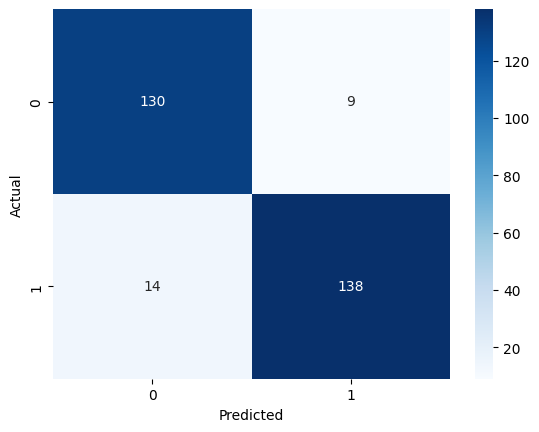

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, test_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import pickle
pickle.dump(model1,open('model1.pkl','wb'))
model1 = pickle.load(open('model1.pkl','rb'))

## **Model 2: svm**

In [ ]:
from sklearn.svm import SVC
model2 = SVC()
model2.fit(X_train,Y_train)

SVC()

In [ ]:
ym_pred = model2.predict(X_val)
accuracy_score(Y_val,ym_pred)
print(confusion_matrix(Y_val,ym_pred))
print(classification_report(Y_val,ym_pred))

[[152  57]
 [  8 219]]
              precision    recall  f1-score   support

           0       0.95      0.73      0.82       209
           1       0.79      0.96      0.87       227

    accuracy                           0.85       436
   macro avg       0.87      0.85      0.85       436
weighted avg       0.87      0.85      0.85       436



In [ ]:
ymtest_pred = model2.predict(X_test)
accuracy_score(Y_test,ymtest_pred)
print(confusion_matrix(Y_test,ymtest_pred))
print(classification_report(Y_test,ymtest_pred))


[[103  36]
 [  7 145]]
              precision    recall  f1-score   support

           0       0.94      0.74      0.83       139
           1       0.80      0.95      0.87       152

    accuracy                           0.85       291
   macro avg       0.87      0.85      0.85       291
weighted avg       0.87      0.85      0.85       291



In [ ]:
pickle.dump(model2,open('model2.pkl','wb'))
model2 = pickle.load(open('model2.pkl','rb'))